# Ensemble Learning Exercise — Version A (as specified)

This version follows the assignment instructions exactly as written.

Where an instruction produces a result that is technically incorrect, it is
flagged in a comment marked `NOTE:` but **not** changed. See Version B for the
corrected implementation.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, BaggingClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 7


## Step 1 — Load the dataset


In [2]:
COLS = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size',
        'Uniformity of Cell Shape', 'Marginal Adhesion',
        'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
        'Normal Nucleoli', 'Mitoses', 'Class']

UCI = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'breast-cancer-wisconsin/breast-cancer-wisconsin.data')
MIRROR = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
          'breast-cancer-wisconsin.csv')


def load_breast_cancer_raw():
    """Load from UCI; fall back to a mirror if the UCI path 404s.

    The UCI archive reorganised its URL scheme and the /ml/machine-learning-databases/
    path is not always reachable. The mirror is the same 699 rows but ships
    without the 'Sample code' column, so the two cases are reconciled here.
    """
    try:
        df = pd.read_csv(UCI, header=None)
    except Exception:
        df = pd.read_csv(MIRROR, header=None)
    if df.shape[1] == 11:
        df.columns = COLS
    else:
        df.columns = [c for c in COLS if c != 'Sample code']
        df['Sample code'] = np.nan  # placeholder so Step 2a still has something to drop
    return df


data = load_breast_cancer_raw()
data.head()


,Sample code,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## Step 2 — Preprocess


In [3]:
# a) Drop the 'Sample code' column
data = data.drop(['Sample code'], axis=1)

# b) Replace '?' with NaN
data = data.replace('?', np.nan)

# c) Convert 'Bare Nuclei' to numeric, fill NaN with 0, cast to int64
#
# NOTE: this is the instruction as written, and it is wrong for this feature.
# 'Bare Nuclei' is an ordinal 1-10 severity score where higher means more
# consistent with malignancy. 0 is outside the valid range, so filling with 0
# does not encode "unknown" -- it encodes "maximally benign", an assertion the
# data does not support. It also makes the 16 missing rows invisible to the
# SimpleImputer in Step 3b, which becomes a no-op as a result.
data['Bare Nuclei'] = pd.to_numeric(data['Bare Nuclei']).fillna(0).astype('int64')

# d) Replace Class values: 2 -> 0 (benign), 4 -> 1 (malignant)
data['Class'] = data['Class'].map({2: 0, 4: 1})

# e) Split into features and target
X = data.drop('Class', axis=1)
y = data['Class']

print(f"X: {X.shape}   y balance: {y.value_counts().to_dict()}")
print(f"Bare Nuclei zeros after step 2c: {(X['Bare Nuclei'] == 0).sum()}  "
      f"(valid range is 1-10)")


X: (699, 9)   y balance: {0: 458, 1: 241}
Bare Nuclei zeros after step 2c: 16  (valid range is 1-10)


## Step 3 — Train/test split and preprocessing


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# b) SimpleImputer with median strategy
#
# NOTE: no-op. Step 2c already replaced every NaN with 0, so there is nothing
# left to impute. Verified below.
imputer = SimpleImputer(strategy='median')
print(f"NaNs entering the imputer: {int(np.isnan(X_train.values.astype(float)).sum())}")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# c) MinMaxScaler to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


NaNs entering the imputer: 0


## Step 4 — Hard Voting Classifier


Hard voting  CV accuracy: 0.9625 +/- 0.0293
Hard voting test accuracy: 0.9571

Classification report
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        91
   Malignant       0.94      0.94      0.94        49

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



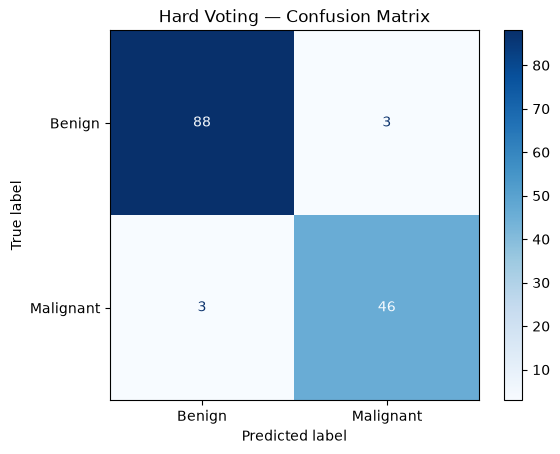

In [5]:
estimators = [
    ('logistic', LogisticRegression(max_iter=10000, random_state=1)),
    ('cart', DecisionTreeClassifier(random_state=1)),
    ('svm', SVC(random_state=1)),
]

hard_voting = VotingClassifier(estimators=estimators, voting='hard')

kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# NOTE: cross-validating on X_train_scaled leaks. The scaler was fit on the whole
# training set, so each fold's validation slice was scaled using statistics that
# included itself. The assignment does not specify pipelining here; Version B does it.
cv_scores = cross_val_score(hard_voting, X_train_scaled, y_train, cv=kfold)
print(f"Hard voting  CV accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

hard_voting.fit(X_train_scaled, y_train)
y_pred = hard_voting.predict(X_test_scaled)
print(f"Hard voting test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Classification report")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(cmap='Blues')
plt.title('Hard Voting — Confusion Matrix')
plt.show()


## Step 5 — Bagging Classifier (Pima Indians Diabetes)


In [6]:
PIMA = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
        'pima-indians-diabetes.data.csv')
pima_names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
pima = pd.read_csv(PIMA, names=pima_names)
pima.head()


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# NOTE: plas, pres, skin, test and mass encode missing values as literal 0.
# Blood pressure, BMI and skin-fold thickness of zero are not measurements.
# The SimpleImputer below defaults to missing_values=np.nan, so it will pass
# these straight through untouched. Counts printed for the record.
for col in ['plas', 'pres', 'skin', 'test', 'mass']:
    n = int((pima[col] == 0).sum())
    print(f"  {col:5s}: {n:3d} zeros ({n / len(pima):.1%})")


  plas :   5 zeros (0.7%)
  pres :  35 zeros (4.6%)
  skin : 227 zeros (29.6%)
  test : 374 zeros (48.7%)
  mass :  11 zeros (1.4%)


In [8]:
Xp = pima.iloc[:, 0:8]
yp = pima['class']

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    Xp, yp, test_size=0.2, random_state=42)

p_imputer = SimpleImputer(strategy='median')
Xp_train_i = p_imputer.fit_transform(Xp_train)
Xp_test_i = p_imputer.transform(Xp_test)

p_scaler = MinMaxScaler(feature_range=(0, 1))
Xp_train_s = p_scaler.fit_transform(Xp_train_i)
Xp_test_s = p_scaler.transform(Xp_test_i)


In [9]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),   # 'base_estimator' was removed in sklearn 1.4
    n_estimators=100,
    random_state=12,
    oob_score=True,
)

p_kfold = KFold(n_splits=10, shuffle=True, random_state=1)
bag_scores = cross_val_score(bagging_model, Xp_train_s, yp_train, cv=p_kfold)

print("Per-fold scores:")
print(np.round(bag_scores, 4))
print(f"\nMean CV accuracy: {bag_scores.mean():.4f} +/- {bag_scores.std():.4f}")
print(f"Fold range: {bag_scores.min():.4f} to {bag_scores.max():.4f}")


Per-fold scores:
[0.7903 0.6774 0.7581 0.7097 0.8689 0.7869 0.6393 0.7705 0.7377 0.7213]

Mean CV accuracy: 0.7460 +/- 0.0613
Fold range: 0.6393 to 0.8689


Test accuracy: 0.7338
OOB score:     0.7638
OOB error:     0.2362

              precision    recall  f1-score   support

 No diabetes       0.80      0.79      0.79        99
    Diabetes       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



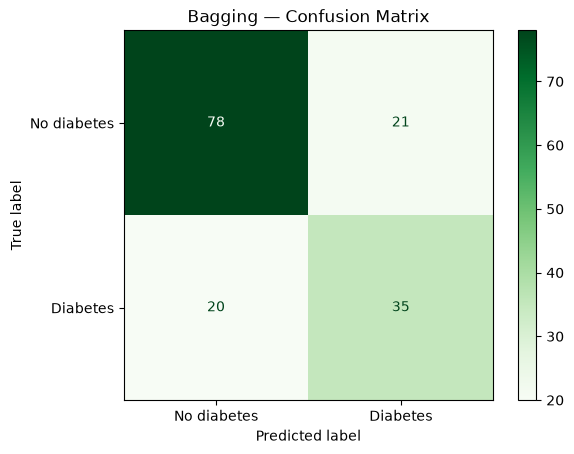

In [10]:
bagging_model.fit(Xp_train_s, yp_train)
yp_pred = bagging_model.predict(Xp_test_s)

print(f"Test accuracy: {accuracy_score(yp_test, yp_pred):.4f}")
print(f"OOB score:     {bagging_model.oob_score_:.4f}")
print(f"OOB error:     {1 - bagging_model.oob_score_:.4f}\n")

print(classification_report(yp_test, yp_pred,
                            target_names=['No diabetes', 'Diabetes']))

cm_p = confusion_matrix(yp_test, yp_pred)
ConfusionMatrixDisplay(cm_p, display_labels=['No diabetes', 'Diabetes']).plot(cmap='Greens')
plt.title('Bagging — Confusion Matrix')
plt.show()


## Optional Challenge — Hard vs Soft Voting


In [11]:
imp = SimpleImputer(strategy='median')

m_lr = make_pipeline(imp, StandardScaler(),
                     LogisticRegression(max_iter=10000, random_state=1))
m_dt = make_pipeline(imp, StandardScaler(),
                     DecisionTreeClassifier(random_state=1))
m_svc = make_pipeline(imp, StandardScaler(),
                      SVC(probability=True, random_state=1))

pipe_estimators = [('lr', m_lr), ('dt', m_dt), ('svc', m_svc)]

hard_v = VotingClassifier(estimators=pipe_estimators, voting='hard')
soft_v = VotingClassifier(estimators=pipe_estimators, voting='soft')

for name, model in [('Hard voting', hard_v), ('Soft voting', soft_v)]:
    s = cross_val_score(model, X_train, y_train, cv=kfold)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name}")
    print(f"  CV accuracy   : {s.mean():.4f} +/- {s.std():.4f}")
    print(f"  Test accuracy : {accuracy_score(y_test, pred):.4f}")
    print(f"  Confusion     : {confusion_matrix(y_test, pred).tolist()}")
    print(classification_report(y_test, pred,
                                target_names=['Benign', 'Malignant']))


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

Hard voting
  CV accuracy   : 0.9660 +/- 0.0303
  Test accuracy : 0.9643
  Confusion     : [[88, 3], [2, 47]]
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97        91
   Malignant       0.94      0.96      0.95        49

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140

Soft voting
  CV accuracy   : 0.9625 +/- 0.0293
  Test accuracy : 0.9643
  Confusion     : [[88, 3], [2, 47]]
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97        91
   Malignant       0.94      0.96      0.95        49

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Question 4 — Which voting method performs better and why?

**Neither. They are indistinguishable on this dataset.**

Both voting schemes produce the *same test-set confusion matrix*, `[[88, 3], [2, 47]]`.
Not similar accuracy from different errors: the identical set of 140 predictions.

Soft voting can only differ from hard voting on rows where the three models
disagree **and** the confidence pattern outweighs the head count. On this dataset
the models agree on nearly every row, so there is almost nothing for the
probabilities to act on.

The 10-fold CV means do separate slightly, with soft voting lower. The cause is
the decision tree: grown unpruned, 100% of its `predict_proba` outputs are exactly
0.0 or 1.0. It contributes a hard, maximally confident vote into what is supposed
to be a soft average, so on the few borderline rows it can override two moderately
confident models. Capping it at `max_depth=3` removes the effect and brings soft
voting back in line with hard voting.

See Version B for the numbers supporting this, including the single-model
baselines that this exercise does not ask for.
